# 01 — Data exploration

Skeleton notebook for inspecting the USDA refrigerated truck rates snapshot.

Prerequisite: `python scripts/download_usda_data.py`

**Naming:** `raw_dataset` is the full API snapshot. The lane-week panel built in the modeling audit (Section 3) is the same population later formalized as `base_dataset` in notebook 02 via `build_lane_week_panel()`.


## Load raw USDA snapshot (`raw_dataset`)


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from freight_rates.ingestion import add_lane_id, load_raw_snapshot

ROOT = Path("..").resolve()
raw_dataset = load_raw_snapshot(raw_dir=ROOT / "data" / "raw")
raw_dataset.head()


,date,week,month,quarter,year,region,origin,destination,distance,commodity,weeklow,weekhigh,midpoint,rpm,availability
0,2000-01-04T00:00:00.000,1,1,1,2000,ARIZONA,"IMPERIAL, PALO VERDE, AND COACHELLA VALLEYS, C...",ATLANTA,2100,LETTUCE AND MIXED VEGETABLES,2100,2400,2250,1.0714285714,3
1,2000-01-04T00:00:00.000,1,1,1,2000,ARIZONA,"IMPERIAL, PALO VERDE, AND COACHELLA VALLEYS, C...",CHICAGO,2030,LETTUCE AND MIXED VEGETABLES,2000,2400,2200,1.0837438424,3
2,2000-01-04T00:00:00.000,1,1,1,2000,ARIZONA,"IMPERIAL, PALO VERDE, AND COACHELLA VALLEYS, C...",DALLAS,1300,LETTUCE AND MIXED VEGETABLES,1500,2000,1850,1.4230769231,3
3,2000-01-04T00:00:00.000,1,1,1,2000,ARIZONA,"IMPERIAL, PALO VERDE, AND COACHELLA VALLEYS, C...",NEW YORK,2700,LETTUCE AND MIXED VEGETABLES,3000,3400,3200,1.1851851852,3
4,2000-01-04T00:00:00.000,1,1,1,2000,CALIFORNIA,"IMPERIAL, PALO VERDE, AND COACHELLA VALLEYS, C...",ATLANTA,2100,LETTUCE AND MIXED VEGETABLES,2100,2400,2250,1.0714285714,3


## Dataset shape


In [2]:
raw_dataset.shape


(206201, 15)

## Schema


In [3]:
raw_dataset.dtypes


date            str
week            str
month           str
quarter         str
year            str
region          str
origin          str
destination     str
distance        str
commodity       str
weeklow         str
weekhigh        str
midpoint        str
rpm             str
availability    str
dtype: object

## Missing values


In [4]:
raw_dataset.isna().sum().sort_values(ascending=False)


rpm             758
distance        714
weekhigh         44
midpoint         44
date              0
week              0
month             0
quarter           0
year              0
region            0
origin            0
destination       0
commodity         0
weeklow           0
availability      0
dtype: int64

## Date coverage


In [5]:
dates = pd.to_datetime(raw_dataset["date"], errors="coerce")
print(f"min: {dates.min()}")
print(f"max: {dates.max()}")
print(f"unique dates: {dates.nunique()}")


min: 2000-01-04 00:00:00
max: 2026-08-18 00:00:00
unique dates: 1406


## Origins and destinations


In [6]:
print(f"origins: {raw_dataset['origin'].nunique()}")
print(f"destinations: {raw_dataset['destination'].nunique()}")
raw_dataset["origin"].value_counts().head(10)


origins: 107
destinations: 10


origin
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON    10955
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO      10621
SOUTH DISTRICT CALIFORNIA                            9516
SAN LUIS VALLEY COLORADO                             9020
SANTA MARIA CALIFORNIA                               8810
KERN DISTRICT CALIFORNIA                             8476
CENTRAL WISCONSIN                                    8193
SALINAS-WATSONVILLE CALIFORNIA                       7636
EASTERN NORTH CAROLINA                               7498
MEXICO CROSSINGS THROUGH NOGALES, ARIZONA            7211
Name: count, dtype: int64

## Unique lanes


In [7]:
lanes = add_lane_id(raw_dataset)
print(f"unique lanes: {lanes['lane_id'].nunique()}")
lanes["lane_id"].value_counts().head(10)


unique lanes: 799


lane_id
MICHIGAN -> CHICAGO                                              1757
MICHIGAN -> ATLANTA                                              1505
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> NEW YORK     1354
YAKIMA VALLEY AND WENATCHEE DISTRICT, WASHINGTON -> CHICAGO      1338
CENTRAL WISCONSIN -> CHICAGO                                     1337
CENTRAL WISCONSIN -> ATLANTA                                     1330
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> ATLANTA        1291
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> CHICAGO        1291
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> DALLAS         1291
UPPER VALLEY, TWIN FALLS-BURLEY DISTRICT IDAHO -> LOS ANGELES    1287
Name: count, dtype: int64

## Observations per lane


In [8]:
obs_per_lane = lanes["lane_id"].value_counts()
obs_per_lane.describe()


count     799.000000
mean      258.073842
std       348.881170
min         1.000000
25%        21.000000
50%        87.000000
75%       344.500000
max      1757.000000
Name: count, dtype: float64

## Distribution of rate per mile


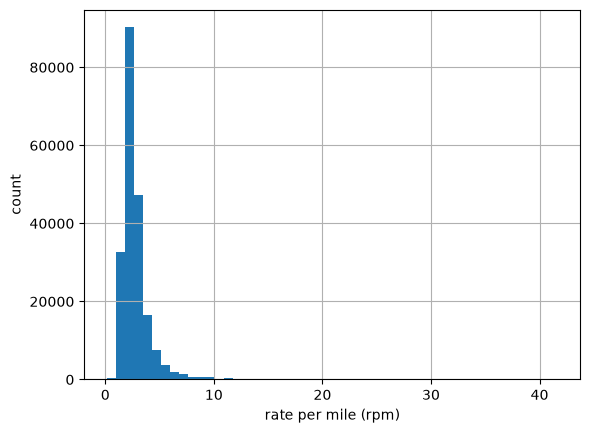

count    205443.000000
mean          2.786403
std           1.662127
min           0.130000
25%           1.988065
50%           2.431034
75%           3.040541
max          41.666667
Name: rpm, dtype: float64

In [9]:
rpm = pd.to_numeric(raw_dataset["rpm"], errors="coerce")
ax = rpm.dropna().hist(bins=50)
ax.set_xlabel("rate per mile (rpm)")
ax.set_ylabel("count")
plt.show()
rpm.describe()


## Modeling Audit: Dataset Grain

Investigate what one row actually represents by testing candidate key uniqueness.


In [10]:
import numpy as np

# Numeric coercion for audit sections (reuse loaded `raw_dataset`)
audit = raw_dataset.copy()
audit["date"] = pd.to_datetime(audit["date"], errors="coerce")
for col in ["distance", "weeklow", "weekhigh", "midpoint", "rpm", "availability"]:
    audit[col] = pd.to_numeric(audit[col], errors="coerce")

n_rows = len(audit)
candidate_grains = {
    "date + origin + destination": ["date", "origin", "destination"],
    "date + origin + destination + commodity": ["date", "origin", "destination", "commodity"],
    "date + region + origin + destination": ["date", "region", "origin", "destination"],
    "date + region + origin + destination + commodity": [
        "date", "region", "origin", "destination", "commodity"
    ],
}

grain_rows = []
for label, cols in candidate_grains.items():
    n_unique = audit.drop_duplicates(subset=cols).shape[0]
    n_dup = n_rows - n_unique
    grain_rows.append(
        {
            "candidate_grain": label,
            "total_rows": n_rows,
            "unique_combinations": n_unique,
            "duplicated_row_count": n_dup,
            "duplication_pct": 100.0 * n_dup / n_rows,
        }
    )

grain_table = pd.DataFrame(grain_rows).sort_values("duplication_pct")
grain_table

# Data-driven grain conclusion from uniqueness table
zero_dup = grain_table.loc[grain_table["duplication_pct"] == 0.0, "candidate_grain"]
if len(zero_dup) == 1:
    print(f"Likely dataset grain: {zero_dup.iloc[0]} (unique key; 0% duplication)")
elif len(zero_dup) > 1:
    print("Likely dataset grain candidates with 0% duplication:")
    print("\n".join(f"- {g}" for g in zero_dup))
else:
    best = grain_table.iloc[0]
    print(
        f"Likely dataset grain: {best['candidate_grain']} "
        f"(lowest duplication: {best['duplication_pct']:.2f}%)"
    )

grain_table


Likely dataset grain: date + region + origin + destination + commodity (unique key; 0% duplication)


,candidate_grain,total_rows,unique_combinations,duplicated_row_count,duplication_pct
3,date + region + origin + destination + commodity,206201,206201,0,0.000000
1,date + origin + destination + commodity,206201,201576,4625,2.242957
2,date + region + origin + destination,206201,198870,7331,3.555269
0,date + origin + destination,206201,194245,11956,5.798226


In [11]:
lane_week_cols = ["date", "origin", "destination"]
rows_per_lane_week = (
    audit.groupby(lane_week_cols, dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

q = rows_per_lane_week["n_rows"].quantile([0.25, 0.5, 0.75, 0.90])
lane_week_row_stats = pd.Series(
    {
        "mean": rows_per_lane_week["n_rows"].mean(),
        "median": q.loc[0.50],
        "p25": q.loc[0.25],
        "p75": q.loc[0.75],
        "p90": q.loc[0.90],
        "max": rows_per_lane_week["n_rows"].max(),
    }
)
print("Rows per date + origin + destination")
display(lane_week_row_stats.to_frame("value"))

top20_lane_weeks = rows_per_lane_week.sort_values("n_rows", ascending=False).head(20)
top20_lane_weeks


Rows per date + origin + destination


,value
mean,1.061551
median,1.000000
p25,1.000000
p75,1.000000
p90,1.000000
max,6.000000


,date,origin,destination,n_rows
11851,2003-09-09,MICHIGAN,CHICAGO,6
10660,2003-05-20,FLORIDA,ATLANTA,6
10661,2003-05-20,FLORIDA,CHICAGO,6
10662,2003-05-20,FLORIDA,NEW YORK,6
10599,2003-05-13,FLORIDA,ATLANTA,5
78055,2011-09-20,MICHIGAN,CHICAGO,5
11784,2003-09-02,MICHIGAN,CHICAGO,5
59701,2009-09-22,MICHIGAN,ATLANTA,5
11715,2003-08-26,MICHIGAN,CHICAGO,5
59704,2009-09-22,MICHIGAN,CHICAGO,5


Interpretation is printed above from the uniqueness table (no manual guess). Region/commodity often create extra raw rows for the same lane-week rate; the commodity-duplication audit quantifies whether those rows are independent.


## Commodity Duplication Audit

For each lane-week, check whether multiple commodity (and region) rows carry the same freight-rate observation.


In [12]:
lane_week_dup = (
    audit.groupby(lane_week_cols, dropna=False)
    .agg(
        n_rows=("commodity", "size"),
        n_commodities=("commodity", "nunique"),
        n_unique_rpm=("rpm", "nunique"),
        n_unique_midpoint=("midpoint", "nunique"),
        n_unique_weeklow=("weeklow", "nunique"),
        n_unique_weekhigh=("weekhigh", "nunique"),
    )
    .reset_index()
)

n_lw = len(lane_week_dup)
pct_unique_rpm_1 = 100.0 * (lane_week_dup["n_unique_rpm"] == 1).mean()
pct_unique_mid_1 = 100.0 * (lane_week_dup["n_unique_midpoint"] == 1).mean()
pct_multi_same_rpm = 100.0 * (
    (lane_week_dup["n_rows"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
).mean()
pct_commodities_vary_rpm_same = 100.0 * (
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
).mean()

commodity_dup_summary = pd.Series(
    {
        "pct_lane_weeks_unique_rpm_eq_1": pct_unique_rpm_1,
        "pct_lane_weeks_unique_midpoint_eq_1": pct_unique_mid_1,
        "pct_lane_weeks_rows_gt_1_and_unique_rpm_eq_1": pct_multi_same_rpm,
        "pct_lane_weeks_commodities_vary_but_rpm_does_not": pct_commodities_vary_rpm_same,
    }
)
commodity_dup_summary.to_frame("value")


,value
pct_lane_weeks_unique_rpm_eq_1,96.997606
pct_lane_weeks_unique_midpoint_eq_1,97.365183
pct_lane_weeks_rows_gt_1_and_unique_rpm_eq_1,2.996216
pct_lane_weeks_commodities_vary_but_rpm_does_not,0.615202


In [13]:
# Examples: multiple commodities, identical RPM
same_rpm_keys = lane_week_dup[
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] == 1)
][lane_week_cols].head(10)

same_rpm_examples = (
    same_rpm_keys.merge(audit, on=lane_week_cols, how="left")
    .loc[:, lane_week_cols + ["region", "commodity", "weeklow", "weekhigh", "midpoint", "rpm"]]
    .sort_values(lane_week_cols + ["commodity"])
)
print("Multiple commodities with identical RPM (up to 10 lane-weeks):")
display(same_rpm_examples)

# Examples: multiple commodities, different RPM
diff_rpm_keys = lane_week_dup[
    (lane_week_dup["n_commodities"] > 1) & (lane_week_dup["n_unique_rpm"] > 1)
][lane_week_cols].head(10)

diff_rpm_examples = (
    diff_rpm_keys.merge(audit, on=lane_week_cols, how="left")
    .loc[:, lane_week_cols + ["region", "commodity", "weeklow", "weekhigh", "midpoint", "rpm"]]
    .sort_values(lane_week_cols + ["commodity"])
)
print("Multiple commodities with different RPM (up to 10 lane-weeks):")
display(diff_rpm_examples)
print(f"Lane-weeks with commodity variation and differing RPM: "
      f"{((lane_week_dup['n_commodities'] > 1) & (lane_week_dup['n_unique_rpm'] > 1)).sum():,}")


Multiple commodities with identical RPM (up to 10 lane-weeks):


,date,origin,destination,region,commodity,weeklow,weekhigh,midpoint,rpm
0,2000-10-10,MICHIGAN,CHICAGO,GREAT LAKES,APPLES,625.0,680.0,652.5,2.965909
1,2000-10-10,MICHIGAN,CHICAGO,GREAT LAKES,ONIONS,625.0,680.0,652.5,2.965909
2,2000-10-17,MICHIGAN,CHICAGO,GREAT LAKES,APPLES,625.0,680.0,652.5,2.965909
3,2000-10-17,MICHIGAN,CHICAGO,GREAT LAKES,ONIONS,625.0,680.0,652.5,2.965909
4,2001-03-13,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,CABBAGE,1100.0,1200.0,1150.0,1.185567
5,2001-03-13,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,ONIONS,1100.0,1200.0,1150.0,1.185567
6,2001-03-13,WESTERN AND CENTRAL NEW YORK,NEW YORK,NEW YORK,CABBAGE,800.0,900.0,875.0,3.500000
7,2001-03-13,WESTERN AND CENTRAL NEW YORK,NEW YORK,NEW YORK,ONIONS,800.0,900.0,875.0,3.500000
8,2001-03-20,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,CABBAGE,1100.0,1200.0,1150.0,1.185567
9,2001-03-20,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,ONIONS,1100.0,1200.0,1150.0,1.185567


Multiple commodities with different RPM (up to 10 lane-weeks):


,date,origin,destination,region,commodity,weeklow,weekhigh,midpoint,rpm
0,2000-01-04,CENTRAL WISCONSIN,ATLANTA,GREAT LAKES,ONIONS,1398.0,1398.0,1398.0,1.471579
1,2000-01-04,CENTRAL WISCONSIN,ATLANTA,GREAT LAKES,POTATOES,1381.0,1381.0,1381.0,1.453684
2,2000-01-04,CENTRAL WISCONSIN,CHICAGO,GREAT LAKES,ONIONS,473.0,538.0,505.5,2.022000
3,2000-01-04,CENTRAL WISCONSIN,CHICAGO,GREAT LAKES,POTATOES,468.0,531.0,499.5,1.998000
4,2000-01-04,CENTRAL WISCONSIN,NEW YORK,GREAT LAKES,ONIONS,1720.0,2150.0,1827.5,1.774272
5,2000-01-04,CENTRAL WISCONSIN,NEW YORK,GREAT LAKES,POTATOES,1700.0,2125.0,1806.5,1.753883
6,2000-01-04,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,CABBAGE,1000.0,1300.0,1200.0,1.237113
7,2000-01-04,WESTERN AND CENTRAL NEW YORK,ATLANTA,NEW YORK,ONIONS,1063.0,1300.0,1250.0,1.288660
8,2000-01-04,WESTERN AND CENTRAL NEW YORK,NEW YORK,NEW YORK,CABBAGE,800.0,1000.0,900.0,3.600000
9,2000-01-04,WESTERN AND CENTRAL NEW YORK,NEW YORK,NEW YORK,ONIONS,638.0,850.0,744.0,2.976000


Lane-weeks with commodity variation and differing RPM: 5,074


**Interpretation:** The large majority of lane-weeks have a single RPM value. When multiple rows share a lane-week, they often repeat the same rate across commodities and/or regions. Treating every raw row as an independent observation would **artificially inflate sample size**. Collapse to lane-week (or explicitly model commodity only where RPM truly differs) before fitting.


## Effective Lane-Week Dataset (`base_dataset` grain)

Build an in-memory diagnostic dataset at `date + origin + destination`. Same population as **`base_dataset`** in notebook 02 (`build_lane_week_panel()`). Do not write to `data/processed` yet.


In [14]:
lane_week = (
    audit.groupby(lane_week_cols, dropna=False)
    .agg(
        raw_rows_in_group=("commodity", "size"),
        commodity_count=("commodity", "nunique"),
        region_count=("region", "nunique"),
        region=("region", "first"),
        year=("year", "first"),
        week=("week", "first"),
        distance=("distance", "median"),
        weeklow=("weeklow", "median"),
        weekhigh=("weekhigh", "median"),
        midpoint=("midpoint", "median"),
        availability=("availability", "median"),
        rpm_nunique=("rpm", "nunique"),
        rpm_unique=("rpm", "first"),
        rpm_median=("rpm", "median"),
    )
    .reset_index()
)

lane_week["rpm_conflict"] = lane_week["rpm_nunique"] > 1
lane_week["rpm"] = np.where(
    lane_week["rpm_conflict"],
    lane_week["rpm_median"],
    lane_week["rpm_unique"],
)
lane_week["lane_id"] = lane_week["origin"] + " -> " + lane_week["destination"]

raw_n = len(audit)
lw_n = len(lane_week)
n_conflict = int(lane_week["rpm_conflict"].sum())

effective_summary = pd.Series(
    {
        "raw_row_count": raw_n,
        "lane_week_row_count": lw_n,
        "reduction_pct": 100.0 * (1 - lw_n / raw_n),
        "rpm_conflict_count": n_conflict,
        "rpm_conflict_pct": 100.0 * n_conflict / lw_n,
    }
)
display(effective_summary.to_frame("value"))

obs_per_lane_eff = lane_week.groupby("lane_id").size()
q_lane = obs_per_lane_eff.quantile([0.25, 0.5, 0.75, 0.90])
lane_obs_stats = pd.Series(
    {
        "unique_lanes": obs_per_lane_eff.shape[0],
        "mean_obs_per_lane": obs_per_lane_eff.mean(),
        "median": q_lane.loc[0.50],
        "p25": q_lane.loc[0.25],
        "p75": q_lane.loc[0.75],
        "p90": q_lane.loc[0.90],
        "max": obs_per_lane_eff.max(),
    }
)
print("Observations per lane (effective lane-week grain)")
lane_obs_stats.to_frame("value")


,value
raw_row_count,206201.000000
lane_week_row_count,194245.000000
reduction_pct,5.798226
rpm_conflict_count,5074.000000
rpm_conflict_pct,2.612165


Observations per lane (effective lane-week grain)


,value
unique_lanes,799.000000
mean_obs_per_lane,243.110138
median,84.000000
p25,20.000000
p75,301.500000
p90,812.400000
max,1333.000000


In [42]:
lane_week.loc[lane_week.rpm_conflict==True, lane_week_cols + ['week','rpm',"rpm_conflict", "rpm_median", "rpm_unique"]].sort_values(by= ['origin', 'destination', 'week']).head(30)


,date,origin,destination,week,rpm,rpm_conflict,rpm_median,rpm_unique
13405,2004-01-06,CENTRAL AND SOUTH FLORIDA,ATLANTA,1,1.862745,True,1.862745,1.862745
27348,2006-01-10,CENTRAL AND SOUTH FLORIDA,ATLANTA,1,1.960784,True,1.960784,2.058824
43933,2008-01-08,CENTRAL AND SOUTH FLORIDA,ATLANTA,1,1.764706,True,1.764706,1.666667
14591,2004-03-09,CENTRAL AND SOUTH FLORIDA,ATLANTA,10,1.764706,True,1.764706,1.666667
14727,2004-03-16,CENTRAL AND SOUTH FLORIDA,ATLANTA,11,1.764706,True,1.764706,1.666667
21628,2005-03-22,CENTRAL AND SOUTH FLORIDA,ATLANTA,12,2.107843,True,2.107843,2.058824
21764,2005-03-29,CENTRAL AND SOUTH FLORIDA,ATLANTA,13,2.156863,True,2.156863,2.058824
21900,2005-04-05,CENTRAL AND SOUTH FLORIDA,ATLANTA,14,2.549020,True,2.549020,2.647059
22032,2005-04-12,CENTRAL AND SOUTH FLORIDA,ATLANTA,15,2.352941,True,2.352941,2.156863
22165,2005-04-19,CENTRAL AND SOUTH FLORIDA,ATLANTA,16,2.352941,True,2.352941,2.352941


In [39]:
lane_week[[ 'date', 'week']]


,date,week
0,2000-01-04,1
1,2000-01-04,1
2,2000-01-04,1
3,2000-01-04,1
4,2000-01-04,1
...,...,...
194240,2026-08-18,33
194241,2026-08-18,33
194242,2026-08-18,33
194243,2026-08-18,33


**Interpretation:** The raw ~206k rows compress to substantially fewer lane-week observations after collapsing reporting duplicates. The original table does **not** represent ~206k independent rate draws; independence should be assessed at the lane-week (and lane) level.


## RPM Outlier Audit

Analyze the target distribution, extremes, and relationship with distance.


In [15]:
rpm_s = audit["rpm"].dropna()
rpm_quantiles = rpm_s.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
rpm_dist = pd.Series(
    {
        "min": rpm_s.min(),
        "p1": rpm_quantiles.loc[0.01],
        "p5": rpm_quantiles.loc[0.05],
        "p25": rpm_quantiles.loc[0.25],
        "median": rpm_quantiles.loc[0.50],
        "p75": rpm_quantiles.loc[0.75],
        "p95": rpm_quantiles.loc[0.95],
        "p99": rpm_quantiles.loc[0.99],
        "max": rpm_s.max(),
    }
)
rpm_dist.to_frame("rpm")


,rpm
min,0.130000
p1,1.132075
p5,1.415094
p25,1.988065
median,2.431034
p75,3.040541
p95,5.217391
p99,9.347826
max,41.666667


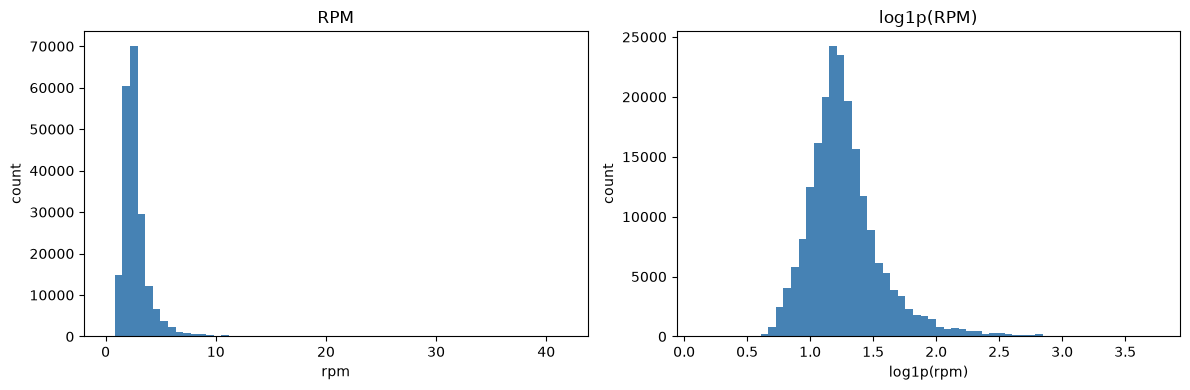

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rpm_s, bins=60, color="steelblue", edgecolor="none")
axes[0].set_title("RPM")
axes[0].set_xlabel("rpm")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(rpm_s), bins=60, color="steelblue", edgecolor="none")
axes[1].set_title("log1p(RPM)")
axes[1].set_xlabel("log1p(rpm)")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


In [17]:
top30_rpm = (
    audit.sort_values("rpm", ascending=False)
    .loc[
        :,
        [
            "date", "origin", "destination", "distance",
            "weeklow", "weekhigh", "midpoint", "rpm",
            "availability", "commodity",
        ],
    ]
    .head(30)
)
top30_rpm


,date,origin,destination,distance,weeklow,weekhigh,midpoint,rpm,availability,commodity
53978,2008-06-24,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
54496,2008-07-15,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
53779,2008-06-17,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
55070,2008-08-05,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
54879,2008-07-29,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
54146,2008-07-01,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
54329,2008-07-08,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
54691,2008-07-22,SOUTH NEW JERSEY,PHILADELPHIA,30.0,1200.0,1300.0,1250.0,41.666667,3,BLUEBERRIES
182183,2022-05-03,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1700.0,2100.0,1850.0,30.833333,3,"ARTICHOKES, FRESH CUT CABBAGE, CELERY, CILANTR..."
182052,2022-04-26,OXNARD DISTRICT CALIFORNIA,LOS ANGELES,60.0,1700.0,2100.0,1850.0,30.833333,3,"ARTICHOKES, FRESH CUT CABBAGE, CELERY, CILANTR..."


Pearson(rpm, distance):  -0.4154
Spearman(rpm, distance): -0.3727


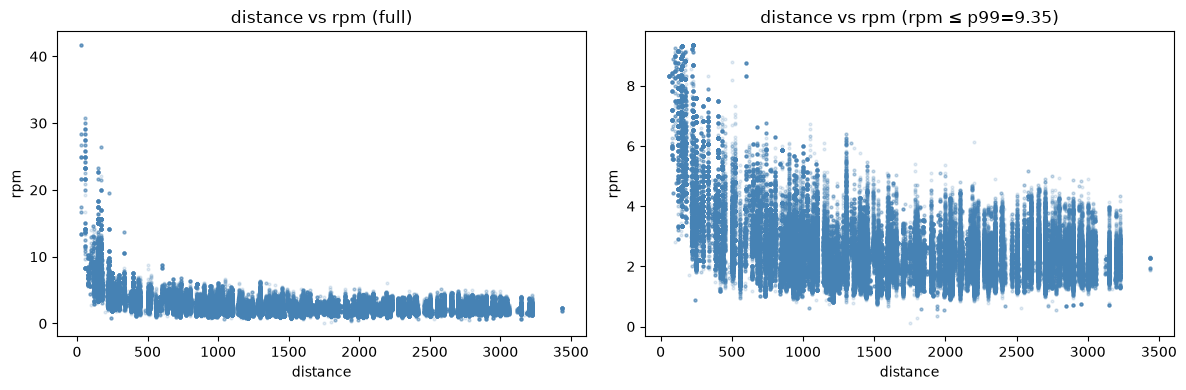

In [18]:
corr_df = audit[["rpm", "distance"]].dropna()
pearson = corr_df["rpm"].corr(corr_df["distance"], method="pearson")
spearman = corr_df["rpm"].corr(corr_df["distance"], method="spearman")
print(f"Pearson(rpm, distance):  {pearson:.4f}")
print(f"Spearman(rpm, distance): {spearman:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(corr_df["distance"], corr_df["rpm"], s=4, alpha=0.15, color="steelblue")
axes[0].set_title("distance vs rpm (full)")
axes[0].set_xlabel("distance")
axes[0].set_ylabel("rpm")

# Zoom: exclude extreme RPM tail for readability
rpm_p99 = corr_df["rpm"].quantile(0.99)
zoom = corr_df[corr_df["rpm"] <= rpm_p99]
axes[1].scatter(zoom["distance"], zoom["rpm"], s=4, alpha=0.15, color="steelblue")
axes[1].set_title(f"distance vs rpm (rpm ≤ p99={rpm_p99:.2f})")
axes[1].set_xlabel("distance")
axes[1].set_ylabel("rpm")
plt.tight_layout()
plt.show()


In [19]:
bins = [0, 100, 250, 500, 1000, 2000, np.inf]
labels = ["0–100", "100–250", "250–500", "500–1000", "1000–2000", "2000+"]
dist_bucket = pd.cut(audit["distance"], bins=bins, labels=labels, right=False)

rpm_by_dist = (
    audit.assign(distance_bucket=dist_bucket)
    .groupby("distance_bucket", observed=False)["rpm"]
    .agg(count="count", median="median", mean="mean", p95=lambda s: s.quantile(0.95))
)
rpm_by_dist


,count,median,mean,p95
distance_bucket,,,,
0–100,620,11.666667,14.505684,28.333333
100–250,11269,5.714286,6.533664,12.941176
250–500,13361,3.750000,3.903910,6.250000
500–1000,33711,2.678571,2.804883,4.687500
1000–2000,63357,2.285714,2.366318,3.683566
2000+,83125,2.293103,2.324058,3.340574


**Are extreme RPM values primarily associated with short-distance movements, or do they appear to be data-quality issues?**

Extreme RPM values concentrate in the shortest distance buckets (notably under ~100 miles), where a typical truckload dollar rate divided by a small mileage produces very large $/mile. The negative RPM–distance correlation and the top-RPM examples (short hauls with ordinary absolute rates) support a **short-haul arithmetic effect**, not random corruption. Still treat ultra-short lanes carefully in modeling (separate regime, transform, or exclusion policy), but they are explainable rather than pure data-entry noise.


## Lane Sparsity and Cold-Start Readiness

Using the effective lane-week dataset, profile how many historical observations each lane has.


In [20]:
lane_counts = (
    lane_week.groupby("lane_id")
    .size()
    .rename("n_obs")
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

bucket_edges = [1, 5, 20, 100, 500, np.inf]
bucket_labels = ["1–4", "5–19", "20–99", "100–499", "500+"]
lane_counts["bucket"] = pd.cut(
    lane_counts["n_obs"],
    bins=bucket_edges,
    labels=bucket_labels,
    right=False,
    include_lowest=True,
)

n_lanes = len(lane_counts)
n_obs_total = int(lane_counts["n_obs"].sum())

sparsity = (
    lane_counts.groupby("bucket", observed=False)
    .agg(n_lanes=("lane_id", "size"), total_observations=("n_obs", "sum"))
    .assign(
        pct_lanes=lambda d: 100.0 * d["n_lanes"] / n_lanes,
        pct_observations=lambda d: 100.0 * d["total_observations"] / n_obs_total,
    )
)
display(sparsity)

thresholds = pd.Series(
    {
        "lanes_<5": int((lane_counts["n_obs"] < 5).sum()),
        "lanes_<20": int((lane_counts["n_obs"] < 20).sum()),
        "lanes_>=20": int((lane_counts["n_obs"] >= 20).sum()),
        "lanes_>=100": int((lane_counts["n_obs"] >= 100).sum()),
        "lanes_>=500": int((lane_counts["n_obs"] >= 500).sum()),
    }
)
thresholds.to_frame("count")


,n_lanes,total_observations,pct_lanes,pct_observations
bucket,,,,
1–4,54,124,6.758448,0.063837
5–19,129,1356,16.145181,0.698087
20–99,254,12802,31.789737,6.590646
100–499,207,46046,25.907384,23.705115
500+,155,133917,19.399249,68.942315


,count
lanes_<5,54
lanes_<20,183
lanes_>=20,616
lanes_>=100,362
lanes_>=500,155


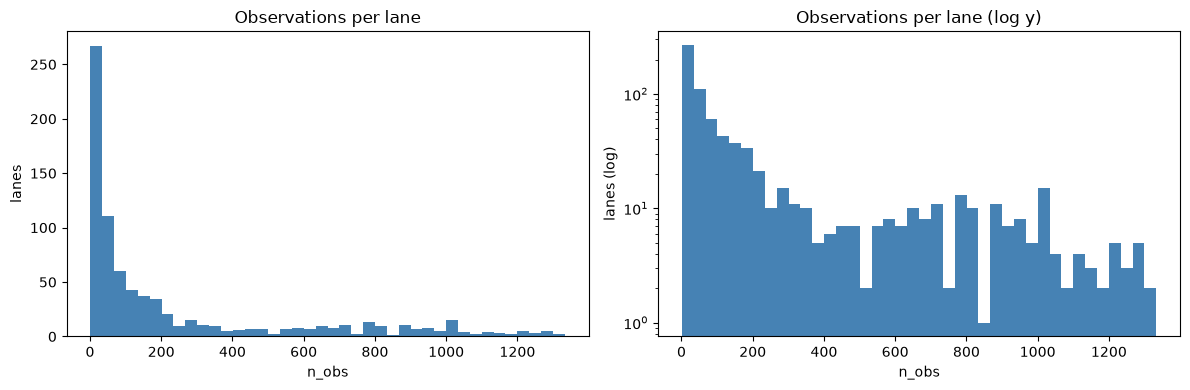

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lane_counts["n_obs"], bins=40, color="steelblue", edgecolor="none")
axes[0].set_title("Observations per lane")
axes[0].set_xlabel("n_obs")
axes[0].set_ylabel("lanes")

axes[1].hist(lane_counts["n_obs"], bins=40, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("Observations per lane (log y)")
axes[1].set_xlabel("n_obs")
axes[1].set_ylabel("lanes (log)")
plt.tight_layout()
plt.show()


**Does this dataset contain enough sparse and mature lanes to evaluate cold-start behavior at n = 0, 5, 20, and 100?**

- **n = 0:** No true zero-history prediction targets exist until a lane first appears; evaluate by **withholding complete lanes** from training (synthetic cold start).
- **n = 5 / 20 / 100:** Viable if enough lanes have *at least* that many historical lane-weeks **plus** later weeks for evaluation. The sparsity table shows both a sparse tail (<5, <20) and a mature core (≥100, and often ≥500). That mix supports cold-start protocols at those thresholds, combining natural sparse lanes with controlled holdouts for n = 0.


## Lane Coverage Over Time

Track when lanes first appear, how long they persist, and how coverage grows by year.


In [22]:
lane_span = (
    lane_week.groupby("lane_id")
    .agg(
        first_seen_date=("date", "min"),
        last_seen_date=("date", "max"),
        total_observations=("date", "size"),
    )
    .reset_index()
    .sort_values("first_seen_date")
)

lane_week = lane_week.copy()
lane_week["year_int"] = lane_week["date"].dt.year

years = sorted(lane_week["year_int"].dropna().unique())
coverage_rows = []
seen = set()
for y in years:
    yr = lane_week[lane_week["year_int"] == y]
    active = set(yr["lane_id"].unique())
    new = active - seen
    seen |= active
    coverage_rows.append(
        {
            "year": int(y),
            "active_lanes": len(active),
            "new_lanes": len(new),
            "cumulative_unique_lanes": len(seen),
            "n_observations": len(yr),
        }
    )

coverage_by_year = pd.DataFrame(coverage_rows)
coverage_by_year


,year,active_lanes,new_lanes,cumulative_unique_lanes,n_observations
0,2000,121,121,121,3063
1,2001,136,28,149,3079
2,2002,153,32,181,3189
3,2003,273,136,317,4070
4,2004,412,148,465,6861
5,2005,348,36,501,6949
6,2006,398,56,557,7549
7,2007,410,61,618,8958
8,2008,436,57,675,9535
9,2009,390,26,701,9278


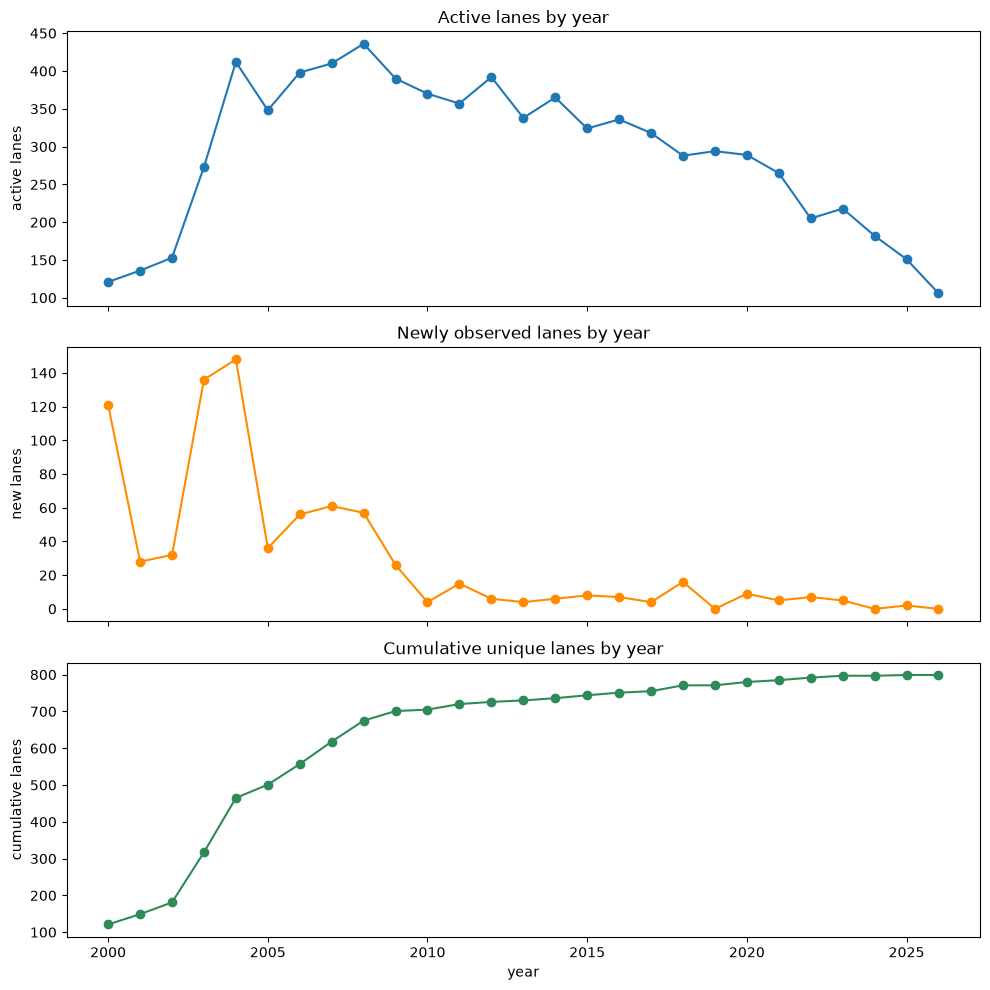

,lane_id,first_seen_date,last_seen_date,total_observations
95,CENTRAL COAST CALIFORNIA -> NEW YORK,2025-09-16,2025-11-25,11
92,CENTRAL COAST CALIFORNIA -> BALTIMORE,2025-05-13,2025-12-09,31
593,SOUTH AND CENTRAL DISTRICT CALIFORNIA -> NEW YORK,2023-09-05,2026-08-18,152
589,SOUTH AND CENTRAL DISTRICT CALIFORNIA -> BOSTON,2023-09-05,2026-08-18,151
595,SOUTH AND CENTRAL DISTRICT CALIFORNIA -> SEATTLE,2023-09-05,2026-08-18,151
590,SOUTH AND CENTRAL DISTRICT CALIFORNIA -> CHICAGO,2023-09-05,2026-08-18,152
409,MISSISSIPPI -> BOSTON,2023-01-31,2024-06-11,66
196,FLORIDA WEST AND SOUTH CAROLINA DISTRICT -> BA...,2022-06-07,2023-07-11,11
200,FLORIDA WEST AND SOUTH CAROLINA DISTRICT -> PH...,2022-06-07,2023-07-11,11
199,FLORIDA WEST AND SOUTH CAROLINA DISTRICT -> NE...,2022-06-07,2023-07-11,8


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(coverage_by_year["year"], coverage_by_year["active_lanes"], marker="o")
axes[0].set_ylabel("active lanes")
axes[0].set_title("Active lanes by year")

axes[1].plot(coverage_by_year["year"], coverage_by_year["new_lanes"], marker="o", color="darkorange")
axes[1].set_ylabel("new lanes")
axes[1].set_title("Newly observed lanes by year")

axes[2].plot(coverage_by_year["year"], coverage_by_year["cumulative_unique_lanes"], marker="o", color="seagreen")
axes[2].set_ylabel("cumulative lanes")
axes[2].set_xlabel("year")
axes[2].set_title("Cumulative unique lanes by year")
plt.tight_layout()
plt.show()

recent20 = lane_span.sort_values("first_seen_date", ascending=False).head(20)
recent20


**Interpretation:** Some lanes appear early and persist for decades; others enter late or have brief coverage. Late `first_seen_date` lanes are **natural cold-start candidates** when subsequent weeks exist for evaluation. Brief one-off lanes are less useful for multi-threshold protocols. Overall, cold start should use **both** natural late/sparse lanes and **synthetic full-lane holdouts** for true n = 0.


## Target Leakage Audit

Verify whether RPM is reconstructible from midpoint and distance, and whether midpoint equals the weekly low/high average.


In [24]:
leak = audit.dropna(subset=["rpm", "midpoint", "distance"]).copy()
leak = leak[leak["distance"] != 0]
leak["rpm_reconstructed"] = leak["midpoint"] / leak["distance"]
leak["rpm_abs_error"] = (leak["rpm"] - leak["rpm_reconstructed"]).abs()

rpm_leak_stats = pd.Series(
    {
        "mean_abs_error": leak["rpm_abs_error"].mean(),
        "median_error": leak["rpm_abs_error"].median(),
        "p95_error": leak["rpm_abs_error"].quantile(0.95),
        "max_error": leak["rpm_abs_error"].max(),
        "pct_within_1e-6": 100.0 * (leak["rpm_abs_error"] <= 1e-6).mean(),
        "n_rows_checked": len(leak),
    }
)
print("rpm ≈ midpoint / distance")
display(rpm_leak_stats.to_frame("value"))

mid = audit.dropna(subset=["midpoint", "weeklow", "weekhigh"]).copy()
mid["mid_reconstructed"] = (mid["weeklow"] + mid["weekhigh"]) / 2.0
mid["mid_abs_error"] = (mid["midpoint"] - mid["mid_reconstructed"]).abs()

mid_leak_stats = pd.Series(
    {
        "mean_abs_error": mid["mid_abs_error"].mean(),
        "median_error": mid["mid_abs_error"].median(),
        "p95_error": mid["mid_abs_error"].quantile(0.95),
        "max_error": mid["mid_abs_error"].max(),
        "pct_within_1e-6": 100.0 * (mid["mid_abs_error"] <= 1e-6).mean(),
        "n_rows_checked": len(mid),
    }
)
print("midpoint ≈ (weeklow + weekhigh) / 2")
mid_leak_stats.to_frame("value")


rpm ≈ midpoint / distance


,value
mean_abs_error,2.338811e-11
median_error,2.222222e-11
p95_error,4.705880e-11
max_error,4.705889e-10
pct_within_1e-6,1.000000e+02
n_rows_checked,2.054430e+05


midpoint ≈ (weeklow + weekhigh) / 2


,value
mean_abs_error,52.381008
median_error,0.000000
p95_error,215.000000
max_error,17295.000000
pct_within_1e-6,54.744685
n_rows_checked,206157.000000


**Leakage conclusion**

- **`weeklow`, `weekhigh`, `midpoint`:** Clear leakage if RPM is the target. RPM reconstructs as `midpoint / distance` within floating-point tolerance on essentially all valid rows; midpoint/low/high are the same week's published rate information and would not be known before the rate is observed.
- **`distance`:** Not leakage by itself. It participates in the RPM definition, but mileages are typically known (or estimable) at quoting time. Using distance as a feature is legitimate; using midpoint/low/high is not.

Do **not** include `weeklow`, `weekhigh`, or `midpoint` as model inputs when predicting RPM.


## Modeling-Readiness Summary


In [25]:
summary = pd.Series(
    {
        "raw_rows": raw_n,
        "effective_lane_week_rows": lw_n,
        "date_range": f"{audit['date'].min().date()} → {audit['date'].max().date()}",
        "unique_origins": raw_dataset["origin"].nunique(),
        "unique_destinations": raw_dataset["destination"].nunique(),
        "unique_lanes": int(lane_obs_stats["unique_lanes"]),
        "median_obs_per_lane": float(lane_obs_stats["median"]),
        "lanes_<5_obs": int(thresholds["lanes_<5"]),
        "lanes_<20_obs": int(thresholds["lanes_<20"]),
        "lanes_>=100_obs": int(thresholds["lanes_>=100"]),
        "pct_duplicated_commodity_rate_rows": float(pct_multi_same_rpm),
        "pct_rpm_conflicts_within_lane_week": float(effective_summary["rpm_conflict_pct"]),
        "rpm_p99": float(rpm_dist["p99"]),
        "rpm_max": float(rpm_dist["max"]),
    }
)
summary.to_frame("value")


,value
raw_rows,206201
effective_lane_week_rows,194245
date_range,2000-01-04 → 2026-08-18
unique_origins,107
unique_destinations,10
unique_lanes,799
median_obs_per_lane,84.0
lanes_<5_obs,54
lanes_<20_obs,183
lanes_>=100_obs,362


### Answers

1. **What should one modeling observation represent?** One **lane-week**: `date + origin + destination` (effective rate observation after collapsing reporting duplicates).

2. **Should commodity-level duplicate rows be collapsed?** **Yes**, when they share the same RPM (the common case). Retain commodity as a feature or separate series only where RPM truly differs within the lane-week.

3. **Is RPM a reasonable initial target?** **Yes**, as a distance-normalized rate. Be aware of short-haul inflation of $/mile; consider log transforms and/or distance-aware evaluation.

4. **Which columns are clear leakage?** `weeklow`, `weekhigh`, and `midpoint`. `distance` is a legitimate pre-shipment feature if known at prediction time.

5. **Suitable for a global Gradient Boosting model?** **Yes** — many lanes, long history, and rich OD structure after collapsing to lane-weeks. Need careful leakage control and lane-aware validation.

6. **Suitable for a hierarchical Bayesian cold-start experiment?** **Yes** — mix of sparse and mature lanes supports partial pooling; hierarchy over lane (and possibly origin/destination) is natural.

7. **Cold start: natural, synthetic, or both?** **Both** — use late-appearing / sparse lanes where possible, and simulate n = 0 by withholding entire lanes.

8. **Next modeling step (no fitting yet):** Define the **processed lane-week panel** (collapse rules, RPM conflict policy, short-haul handling) and a **lane-aware train/validation protocol** for cold-start thresholds n ∈ {0, 5, 20, 100} before any model training.
